# **FastGS vs. Spec-Gaussian**

- **FastGS**: Multi-view-consistency-gated densification for 3DGS. Trains much faster
  than vanilla 3DGS by only densifying Gaussians that several sampled training views
  agree are under-reconstructed. It keeps 3DGS's standard spherical-harmonics (SH)
  color model unchanged.
- **Spec-Gaussian**:  Replaces/augments the per-Gaussian SH color with a
  24-dimensional Anisotropic Spherical Gaussian (ASG) latent, decoded by a small MLP
  into a view-dependent specular RGB residual. This lets 3DGS reproduce sharp,
  view-dependent highlights and reflections that low-order SH cannot represent at
  the cost of a much slower, heavier training loop.

## **Problem statement**

Vanilla 3DGS and FastGS both model per-Gaussian color with spherical harmonics — a
smooth, **low-frequency, Lambertian-biased** basis. This is a poor fit for **specular
reflections and sharp highlights** (metal, glass, glossy plastic, wet surfaces),
whose apparent color changes rapidly and non-smoothly with viewing angle. FastGS makes
densification dramatically faster, but does nothing to fix this, it inherits 3DGS's
specular blind spot exactly.

Spec-Gaussian fixes the *color model* (ASG + MLP can represent sharp, anisotropic,
view-dependent reflectance), but at real cost: **as measured below, it can take an
order of magnitude longer to train** than FastGS on the same scene, and its
densification is still the original 3DGS single-view gradient-threshold scheme, it
does not benefit from FastGS's speedup at all.

**No existing method combines fast, multi-view-consistent densification with accurate
specular reflectance modeling** — FastGS is fast but Lambertian-biased; Spec-Gaussian
is specular-aware but slow and undensified. That is the open gap this notebook
documents.

The rest of this notebook backs each half of that claim with real numbers/renders from
`pipeline-results/` (FastGS and Spec-Gaussian run on shared scenes), not just the
general reputation of each method.

In [8]:
import os, json, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

REPO_ROOT = Path.cwd()
RESULTS_ROOT = REPO_ROOT / "pipeline-results"
assert RESULTS_ROOT.is_dir(), f"pipeline-results not found at {RESULTS_ROOT}"
print("repo root:", REPO_ROOT)
print("pipeline-results:", RESULTS_ROOT)

repo root: d:\Thesis\All
pipeline-results: d:\Thesis\All\pipeline-results


In [9]:
RUNS = {
    # (method, scene, run label): (results.json path, train_info.json path)
    ("FastGS", "counter", "base"):    (RESULTS_ROOT/"FastGS/counter_base/counter/results.json",
                                        RESULTS_ROOT/"FastGS/counter_base/counter/train_info.json"),
    ("FastGS", "counter", "big"):     (RESULTS_ROOT/"FastGS/counter_big/counter_big/results.json",
                                        RESULTS_ROOT/"FastGS/counter_big/counter_big/train_info.json"),
    ("FastGS", "toaster", ""):        (RESULTS_ROOT/"FastGS/toaster/toaster/results.json",
                                        RESULTS_ROOT/"FastGS/toaster/toaster/train_info.json"),
    ("Spec-Gaussian", "counter", "images_8"): (RESULTS_ROOT/"SpecularGaussian/mip360/counter_images_8/results.json",
                                                RESULTS_ROOT/"SpecularGaussian/mip360/counter_images_8/train_info.json"),
    ("Spec-Gaussian", "teapot", ""):  (RESULTS_ROOT/"SpecularGaussian/refnerf/teapot/results.json",
                                        RESULTS_ROOT/"SpecularGaussian/refnerf/teapot/train_info.json"),
    ("Spec-Gaussian", "toaster", ""): (RESULTS_ROOT/"SpecularGaussian/refnerf/toaster/results.json",
                                        RESULTS_ROOT/"SpecularGaussian/refnerf/toaster/train_info.json"),
}

rows = []
for (method, scene, label), (res_path, info_path) in RUNS.items():
    if not res_path.exists():
        print(f"[skip] missing {res_path}")
        continue
    res = json.load(open(res_path))
    key = list(res.keys())[0]
    m = res[key]
    row = {
        "method": method, "scene": scene, "run": label or "default",
        "PSNR": m["PSNR"], "SSIM": m["SSIM"], "LPIPS": m["LPIPS"],
    }
    if info_path.exists():
        info = json.load(open(info_path))
        row["train_time_s"] = info.get("training_time_seconds")
        row["final_gaussians"] = info.get("final_gaussians")
        row["initial_gaussians"] = info.get("initial_gaussians")
    rows.append(row)

df = pd.DataFrame(rows)
df["train_time_min"] = (df["train_time_s"] / 60).round(1)
df = df[["method","scene","run","PSNR","SSIM","LPIPS","train_time_min","initial_gaussians","final_gaussians"]]
df.round(3)

,method,scene,run,PSNR,SSIM,LPIPS,train_time_min,initial_gaussians,final_gaussians
0,FastGS,counter,base,29.166,0.907,0.204,10.0,155767.0,208238.0
1,FastGS,counter,big,29.565,0.917,0.177,14.1,155767.0,468793.0
2,FastGS,toaster,default,21.106,0.888,0.134,3.3,100000.0,51283.0
3,Spec-Gaussian,counter,images_8,30.780,0.941,0.061,NaN,NaN,NaN
4,Spec-Gaussian,teapot,default,45.917,0.996,0.007,11.5,100000.0,24327.0
5,Spec-Gaussian,toaster,default,22.405,0.906,0.100,67.4,100000.0,306462.0


## **Speed vs. quality on `toaster` (Ref-NeRF)**

,method,scene,run,PSNR,SSIM,LPIPS,train_time_min,initial_gaussians,final_gaussians
2,FastGS,toaster,default,21.106,0.888,0.134,3.3,100000.0,51283.0
5,Spec-Gaussian,toaster,default,22.405,0.906,0.100,67.4,100000.0,306462.0


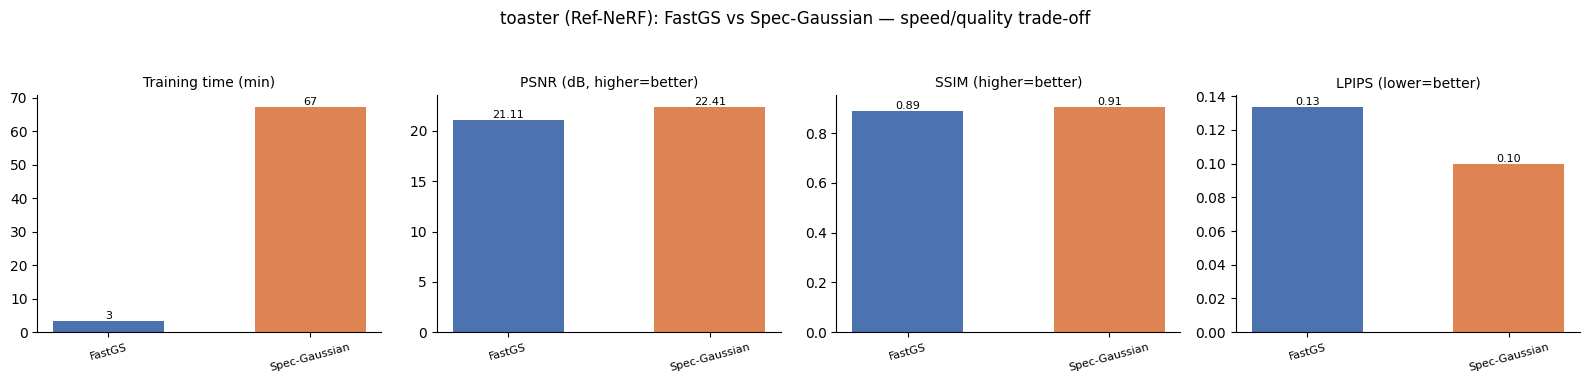


Spec-Gaussian took 20.4x longer to train than FastGS on the identical scene,
for a PSNR gain of +1.30 dB and an LPIPS improvement of +0.034 (LPIPS is a perceptual distance, most sensitive to exactly this kind of fine specular detail).


In [10]:
toaster = df[df["scene"] == "toaster"].copy()
display(toaster.round(3))

METHOD_COLORS = {"FastGS": "#4C72B0", "Spec-Gaussian": "#DD8452"}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
metrics = [("train_time_min", "Training time (min)", False),
           ("PSNR", "PSNR (dB, higher=better)", False),
           ("SSIM", "SSIM (higher=better)", False),
           ("LPIPS", "LPIPS (lower=better)", False)]
for ax, (col, title, logy) in zip(axes, metrics):
    colors = [METHOD_COLORS[m] for m in toaster["method"]]
    bars = ax.bar(toaster["method"], toaster[col], color=colors, width=0.55)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=15, labelsize=8)
    ax.spines[['top','right']].set_visible(False)
    for b, v in zip(bars, toaster[col]):
        ax.annotate(f"{v:.2f}" if col != "train_time_min" else f"{v:.0f}",
                    (b.get_x()+b.get_width()/2, v), ha='center', va='bottom', fontsize=8)
    if logy:
        ax.set_yscale("log")
plt.suptitle("toaster (Ref-NeRF): FastGS vs Spec-Gaussian — speed/quality trade-off", y=1.05)
plt.tight_layout()
plt.savefig("_fig_toaster_tradeoff.png", dpi=130, bbox_inches="tight")
plt.show()

t_fast = toaster.loc[toaster.method=="FastGS", "train_time_min"].values[0]
t_spec = toaster.loc[toaster.method=="Spec-Gaussian", "train_time_min"].values[0]
print(f"\nSpec-Gaussian took {t_spec/t_fast:.1f}x longer to train than FastGS on the identical scene,")
print(f"for a PSNR gain of {(toaster.loc[toaster.method=='Spec-Gaussian','PSNR'].values[0] - toaster.loc[toaster.method=='FastGS','PSNR'].values[0]):+.2f} dB "
      f"and an LPIPS improvement of {(toaster.loc[toaster.method=='FastGS','LPIPS'].values[0] - toaster.loc[toaster.method=='Spec-Gaussian','LPIPS'].values[0]):+.3f} "
      f"(LPIPS is a perceptual distance, most sensitive to exactly this kind of fine specular detail).")

## `counter` (Mip-NeRF 360)

,method,scene,run,PSNR,SSIM,LPIPS,train_time_min,initial_gaussians,final_gaussians,label
0,FastGS,counter,base,29.166,0.907,0.204,10.0,155767.0,208238.0,FastGS (base)
1,FastGS,counter,big,29.565,0.917,0.177,14.1,155767.0,468793.0,FastGS (big)
3,Spec-Gaussian,counter,images_8,30.780,0.941,0.061,NaN,NaN,NaN,Spec-Gaussian (images_8)


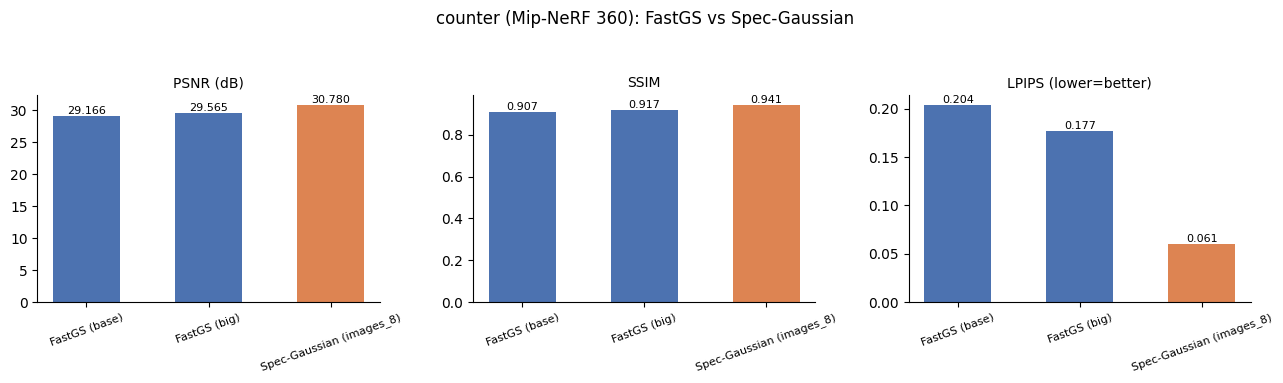

In [11]:
counter = df[df["scene"] == "counter"].copy()
counter["label"] = counter["method"] + " (" + counter["run"] + ")"
display(counter.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
colors = ["#4C72B0", "#4C72B0", "#DD8452"]
for ax, col, title in zip(axes, ["PSNR","SSIM","LPIPS"], ["PSNR (dB)", "SSIM", "LPIPS (lower=better)"]):
    bars = ax.bar(counter["label"], counter[col], color=colors, width=0.55)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.spines[['top','right']].set_visible(False)
    for b, v in zip(bars, counter[col]):
        ax.annotate(f"{v:.3f}", (b.get_x()+b.get_width()/2, v), ha='center', va='bottom', fontsize=8)
plt.suptitle("counter (Mip-NeRF 360): FastGS vs Spec-Gaussian", y=1.05)
plt.tight_layout()
plt.savefig("_fig_counter_metrics.png", dpi=130, bbox_inches="tight")
plt.show()

## **Where does the quality gap actually show up?**

1. Randomly samples `NUM_SAMPLES` shared test views from `toaster` each run (set
   `RANDOM_SEED` to an int to reproduce a specific draw instead).
2. For each view, computes a **specular-region mask on the ground truth** using a
   classical Tan-Ikeuchi + top-hat + desaturation locator, so the reader can see
   exactly *which pixels* are considered hard before looking at either render.
3. Computes a **per-pixel error heatmap** (`|render − GT|`) for both methods, on the
   *same* color scale so the two are directly comparable.
4. Splits PSNR into **inside the specular mask vs. outside it**, per method — this is
   the key diagnostic: it quantifies whether the FastGS/Spec-Gaussian quality gap is
   *concentrated* in specular regions or spread uniformly.

In [12]:
NUM_SAMPLES = 10
RANDOM_SEED = None

import random
from scipy.ndimage import grey_opening

toaster_fastgs_dir = RESULTS_ROOT/"FastGS/toaster/toaster/test/ours_30000"
toaster_specgs_dir = RESULTS_ROOT/"SpecularGaussian/refnerf/toaster/test/ours_30000"

def load01(path):
    return np.array(Image.open(path).convert("RGB")).astype(np.float32) / 255.0

def _disk_footprint(radius):
    y, x = np.ogrid[-radius:radius+1, -radius:radius+1]
    return (x**2 + y**2 <= radius**2)

def specular_mask(gt01, tophat_radius=12, tophat_thresh=0.08, sat_thresh=0.25, bright_floor=0.6):
    # Classical Tan-Ikeuchi-style specular detector, self-contained here (no external
    # imports): a highlight is a pixel whose per-pixel MINIMUM channel (Imin) is
    # LOCALLY elevated (white top-hat: Imin - grey_opening(Imin, disk)), which
    # rejects large flat bright regions the raw value alone can't distinguish from a
    # true highlight, AND desaturated (S < sat_thresh, same formula as Shafer's
    # dichromatic model), AND bright in absolute terms.
    Imin = gt01.min(axis=-1)
    Imax = gt01.max(axis=-1)
    S = np.where(Imax > 1e-6, (Imax - Imin) / (Imax + 1e-6), 0.0)
    opened = grey_opening(Imin, footprint=_disk_footprint(tophat_radius))
    tophat = np.clip(Imin - opened, 0.0, None)
    return (tophat > tophat_thresh) & (Imax > bright_floor) & (S < sat_thresh)

def overlay_mask(img01, mask, color=(1.0, 0.0, 0.0), alpha=0.55):
    out = img01.copy()
    out[mask] = (1 - alpha) * out[mask] + alpha * np.array(color)
    return out

def psnr(a01, b01, mask=None):
    diff = (a01 - b01) ** 2
    if mask is not None:
        if mask.sum() == 0:
            return np.nan
        mse = diff[mask].mean()
    else:
        mse = diff.mean()
    if mse <= 1e-12:
        return 99.0
    return 10 * np.log10(1.0 / mse)

# sample shared test views
all_views = sorted(p.stem for p in (toaster_fastgs_dir/"gt").glob("*.png"))
rng = random.Random(RANDOM_SEED)
sampled_views = rng.sample(all_views, min(NUM_SAMPLES, len(all_views)))
print(f"{len(all_views)} shared test views available; sampled {len(sampled_views)}: {sampled_views}")

200 shared test views available; sampled 10: ['00149', '00080', '00140', '00183', '00106', '00052', '00082', '00122', '00136', '00084']


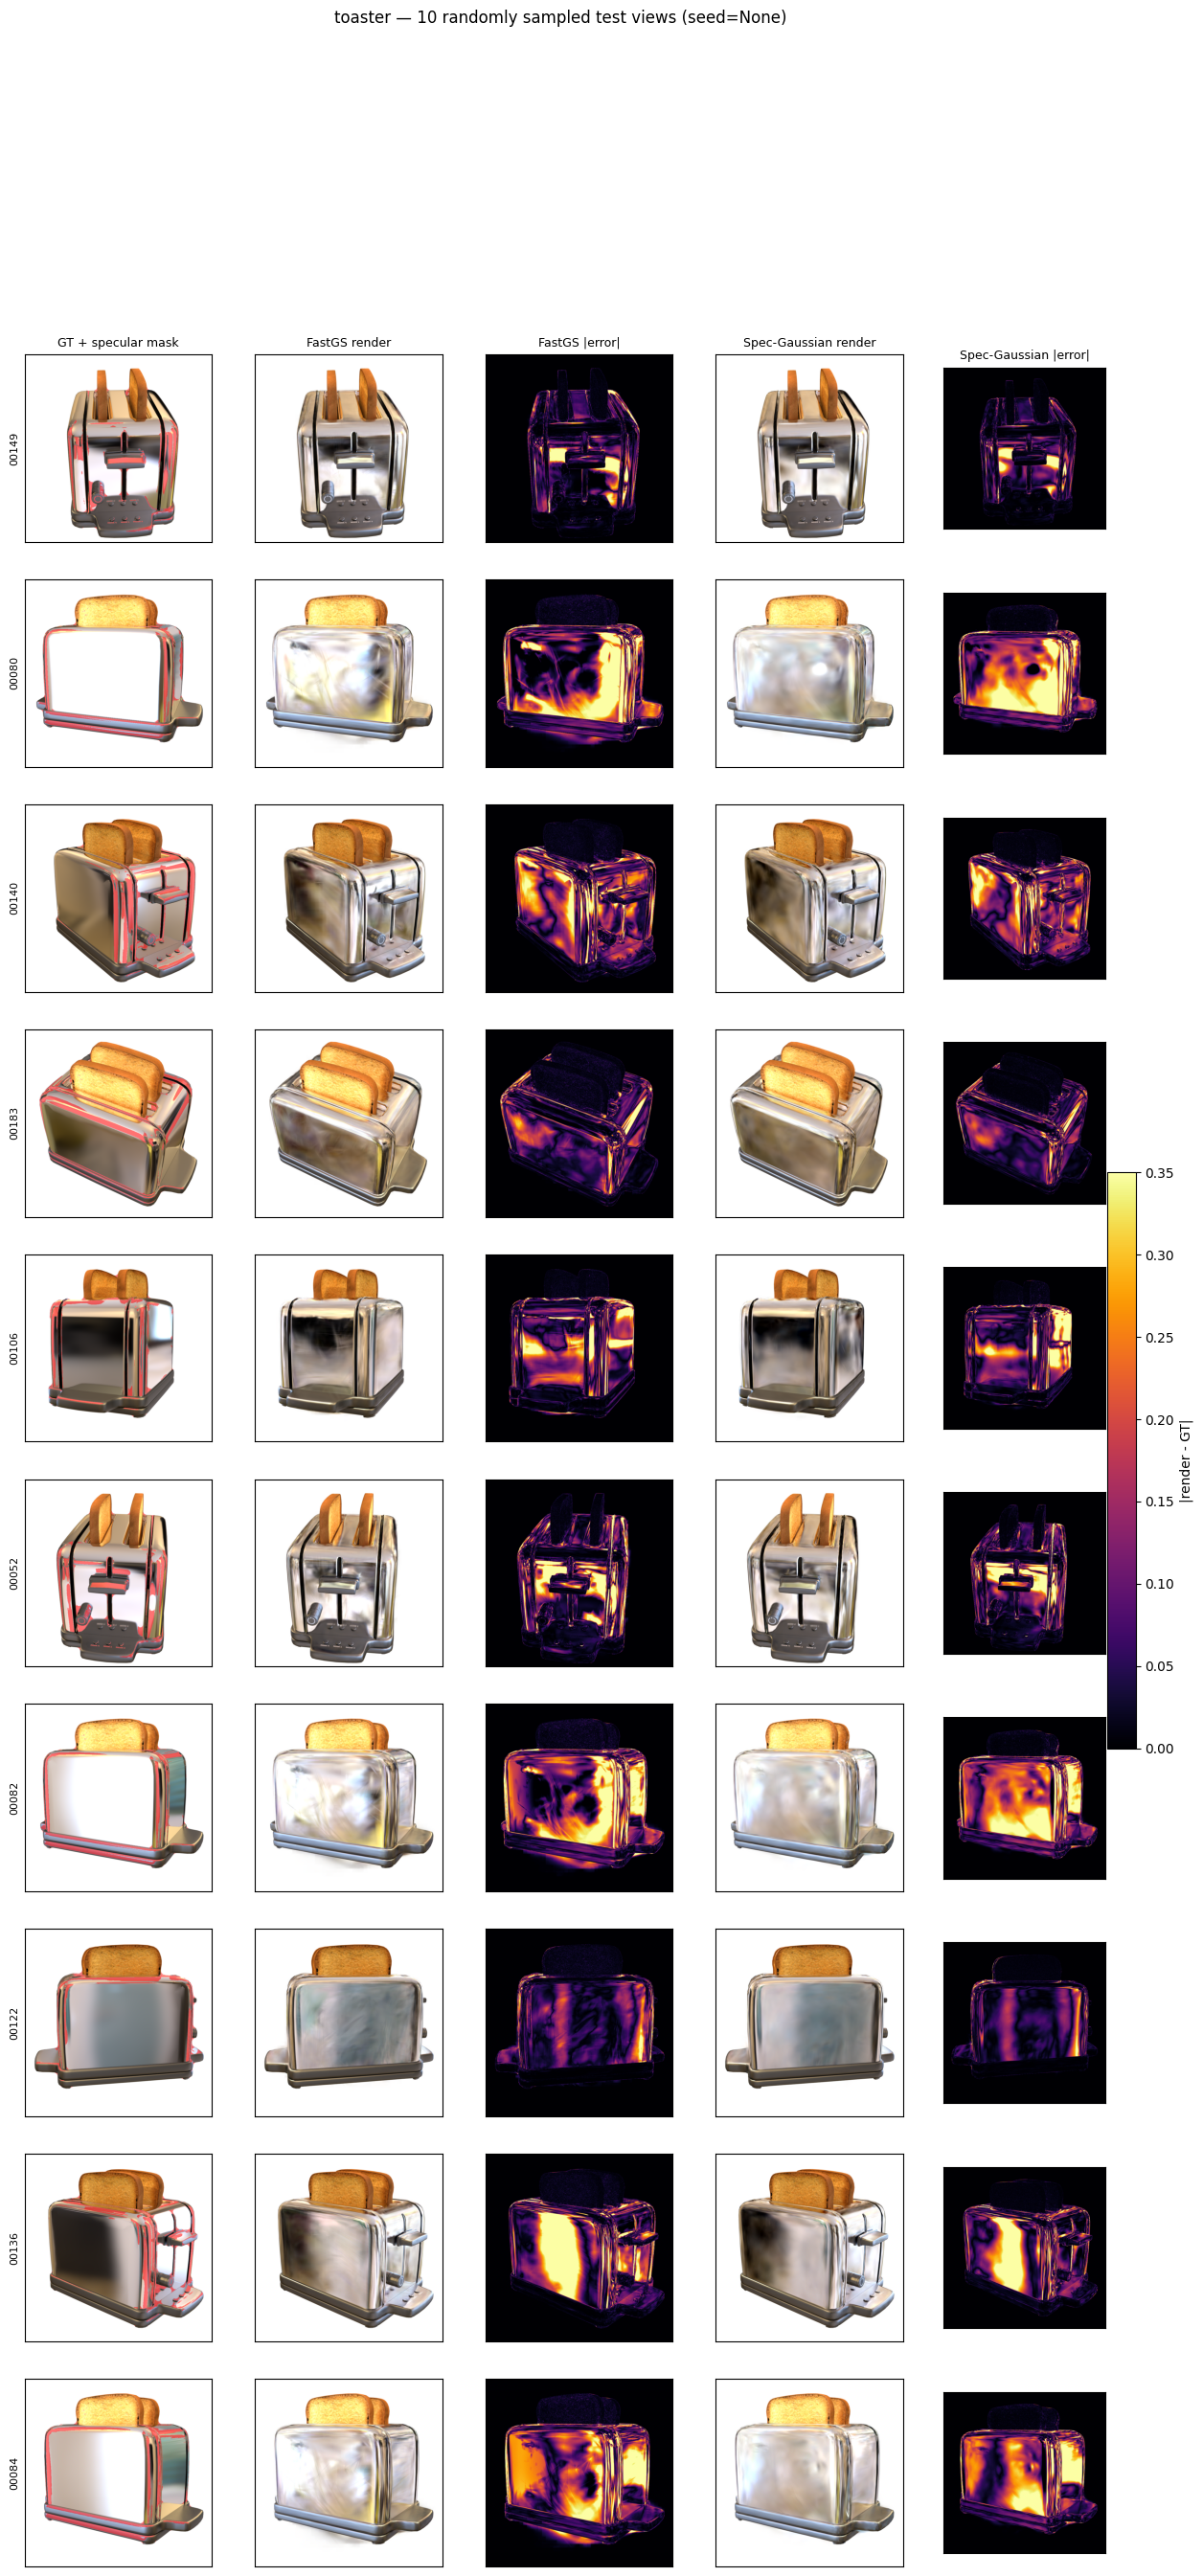

In [13]:
ERROR_VMAX = 0.35  # shared color-scale ceiling for all error heatmaps (errors live in [0,1])

per_view_stats = []
n = len(sampled_views)
fig, axes = plt.subplots(n, 5, figsize=(15, 3.0 * n))
if n == 1:
    axes = axes[None, :]

for row, view in enumerate(sampled_views):
    gt = load01(toaster_fastgs_dir/"gt"/f"{view}.png")
    fastgs_render = load01(toaster_fastgs_dir/"renders"/f"{view}.png")
    specgs_render = load01(toaster_specgs_dir/"renders"/f"{view}.png")

    mask = specular_mask(gt)
    fastgs_err = np.abs(fastgs_render - gt).mean(axis=-1)
    specgs_err = np.abs(specgs_render - gt).mean(axis=-1)

    stats = {
        "view": view,
        "specular_pct": 100.0 * mask.mean(),
        "fastgs_psnr_spec": psnr(fastgs_render, gt, mask),
        "fastgs_psnr_rest": psnr(fastgs_render, gt, ~mask),
        "specgs_psnr_spec": psnr(specgs_render, gt, mask),
        "specgs_psnr_rest": psnr(specgs_render, gt, ~mask),
    }
    per_view_stats.append(stats)

    axes[row,0].imshow(overlay_mask(gt, mask)); axes[row,0].set_ylabel(view, fontsize=8)
    axes[row,1].imshow(fastgs_render)
    axes[row,2].imshow(fastgs_err, cmap="inferno", vmin=0, vmax=ERROR_VMAX)
    axes[row,3].imshow(specgs_render)
    im = axes[row,4].imshow(specgs_err, cmap="inferno", vmin=0, vmax=ERROR_VMAX)
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])
    if row == 0:
        for ax, title in zip(axes[row], ["GT + specular mask", "FastGS render", "FastGS |error|",
                                          "Spec-Gaussian render", "Spec-Gaussian |error|"]):
            ax.set_title(title, fontsize=9)

fig.colorbar(im, ax=axes[:, 4], shrink=0.6, label="|render - GT|", pad=0.01)
plt.suptitle(f"toaster — {n} randomly sampled test views (seed={RANDOM_SEED})", y=1.0)
plt.savefig("_fig_toaster_grid.png", dpi=110, bbox_inches="tight")
plt.show()